# ICU Admission Analysis

This notebook analyzes ICU admission rates in the CDC COVID-19 Case Surveillance dataset.

The cleaned dataset generated in `01_data_acquisition_cleaning_q1.ipynb`
is used to compute ICU admission rates by demographic group.

## Limitation

The 1 million record CDC sample used in this project does not contain all age groups.
As a result, some older age categories are absent from the analysis.

Rates shown here reflect only the age groups present in the extracted sample.
Small groups, such as ages 30–39, should be interpreted cautiously because their denominators are very small.

## Interpretation

In this sample, ICU admission rates are highest for the 40–49 and 50–59 age groups.
However, the sample is not fully representative across age categories, so these findings should be treated as exploratory rather than population-level estimates.

In [1]:
import pandas as pd

df_clean = pd.read_parquet("../data/processed/cdc_clean_1M.parquet")

In [6]:
df_known_icu = df_clean[df_clean['icu_yn'].isin(['Yes', 'No'])].copy()

df_known_icu["age_group"] = (
    df_known_icu["age_group"]
    .str.replace(' Years', '', case=False)
    .str.replace(" ", "", regex=False)
)

df_known_icu = df_known_icu[~df_known_icu['age_group'].isin(['Missing', 'Unknown'])]

df_known_icu.head()

,cdc_report_dt,age_group,sex,race_ethnicity_combined,hosp_yn,icu_yn,death_yn,medcond_yn,current_status,case_month
161,2022-04-01,10-19,Female,Hispanic/Latino,Yes,No,Missing,Yes,Probable Case,2022-04
315,NaT,10-19,Female,Hispanic/Latino,Yes,No,Missing,Missing,Laboratory-confirmed case,NaN
397,2020-08-20,10-19,Female,Hispanic/Latino,Yes,No,Missing,Missing,Laboratory-confirmed case,2020-08
536,NaT,10-19,Female,Hispanic/Latino,Yes,No,Missing,Missing,Laboratory-confirmed case,NaN
887,2020-04-06,10-19,Female,Hispanic/Latino,Yes,No,Missing,Missing,Laboratory-confirmed case,2020-04


In [7]:
age_order = [
    "10-19",
    "20-29",
    "30-39",
    "40-49",
    "50-59",
    "60-69",
    "70-79",
]

icu_cases = (
    df_known_icu.
    groupby('age_group').
    size()
)

icu_admissions = (
    df_known_icu[df_known_icu['icu_yn'] == 'Yes'].
    groupby('age_group').
    size()
)

In [10]:
icu_summary = pd.DataFrame({
    "known_icu_cases": icu_cases,
    "icu_admissions": icu_admissions
})
icu_summary["icu_rate_pct"] = (
    icu_summary["icu_admissions"] / icu_summary["known_icu_cases"] * 100
)

icu_summary = icu_summary.reindex(age_order)
icu_summary = icu_summary.fillna(0)
icu_summary['icu_rate_pct'] = icu_summary['icu_rate_pct'].round(2)

In [11]:
icu_summary

,known_icu_cases,icu_admissions,icu_rate_pct
age_group,,,
10-19,7594.0,107.0,1.41
20-29,2000.0,35.0,1.75
30-39,16.0,1.0,6.25
40-49,7218.0,988.0,13.69
50-59,2441.0,160.0,6.55
60-69,0.0,0.0,0.00
70-79,0.0,0.0,0.00


In [12]:
icu_summary.to_csv('../outputs/icu_by_age.csv')

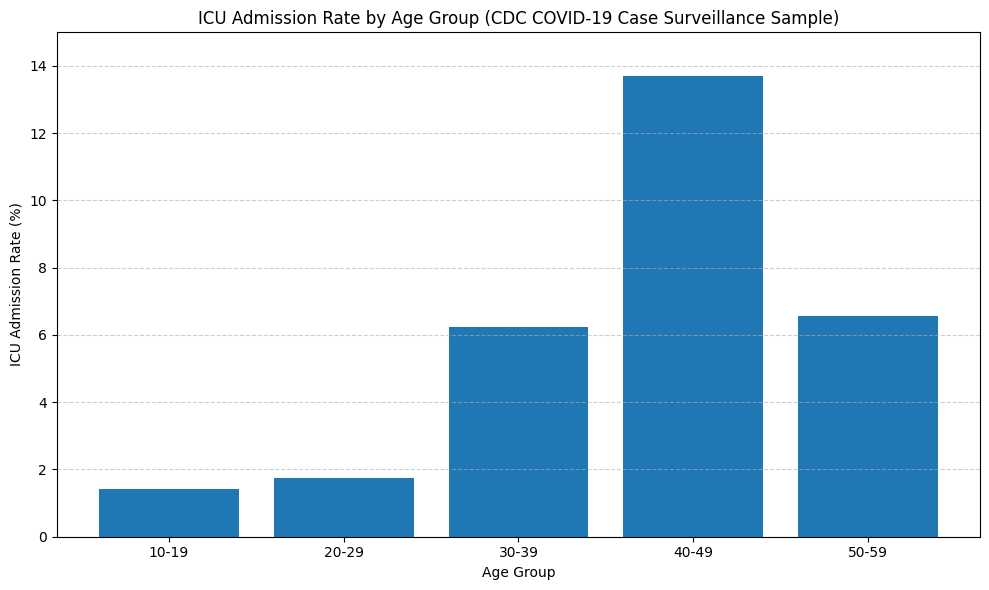

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plot_df = icu_summary[icu_summary['known_icu_cases'] > 0]

plt.bar(
    plot_df.index,
    plot_df["icu_rate_pct"]
)

plt.xlabel("Age Group")
plt.ylabel("ICU Admission Rate (%)")
plt.ylim(0, 15)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.title("ICU Admission Rate by Age Group (CDC COVID-19 Case Surveillance Sample)")

plt.tight_layout()

plt.savefig("../outputs/icu_by_age.png")
plt.show()